In [1]:
import sys, os
import pandas as pd

In [2]:
from NNMFit.utilities import PseudoexpHandler

In [7]:
# pse_path = '/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/pse'
# # minimizer = 'force_full_3_nlight_20'
# minimizer = 'LBFGSB'
# indir = f'{pse_path}/{minimizer}/pse_hese_spectrum_bestfit_13year_n500_round3'

# indir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/debug_pse/LBFGSB/pse_hese_spectrum_bestfit_13year_nominalDetSys_n500/"
indir = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/hese/unblind/step1_hese_flux/debug_pse/LBFGSB/pse_hese_spectrum_bestfit_13year_nominalDetSys_noGradient_n500/"

hdl=PseudoexpHandler(
        indir=indir,
        force_read=True,
        mask_unsuccessful=True,
    )

In [9]:
hdl.get_pseudoexp_df()
# hdl.get_param_results("dom_eff")
hdl.get_injected_values()

{'astro_norm': 2.2442548547245496,
 'gamma_astro': 2.81752715186688,
 'CR_grad': -0.30174744927067926,
 'barr_h': 0.004260894125801356,
 'barr_w': 0.03613960115381407,
 'barr_y': 0.11519971610547383,
 'barr_z': 0.05936337444350018,
 'conv_norm': 1.0638217360248496,
 'delta_gamma': -0.002431016314179412,
 'effective_veto': 1.0,
 'muongun_norm_cascade': 1.0,
 'muongun_norm': 1.4572392109257732,
 'muon_norm': 1.0,
 'prompt_norm': 0.0}

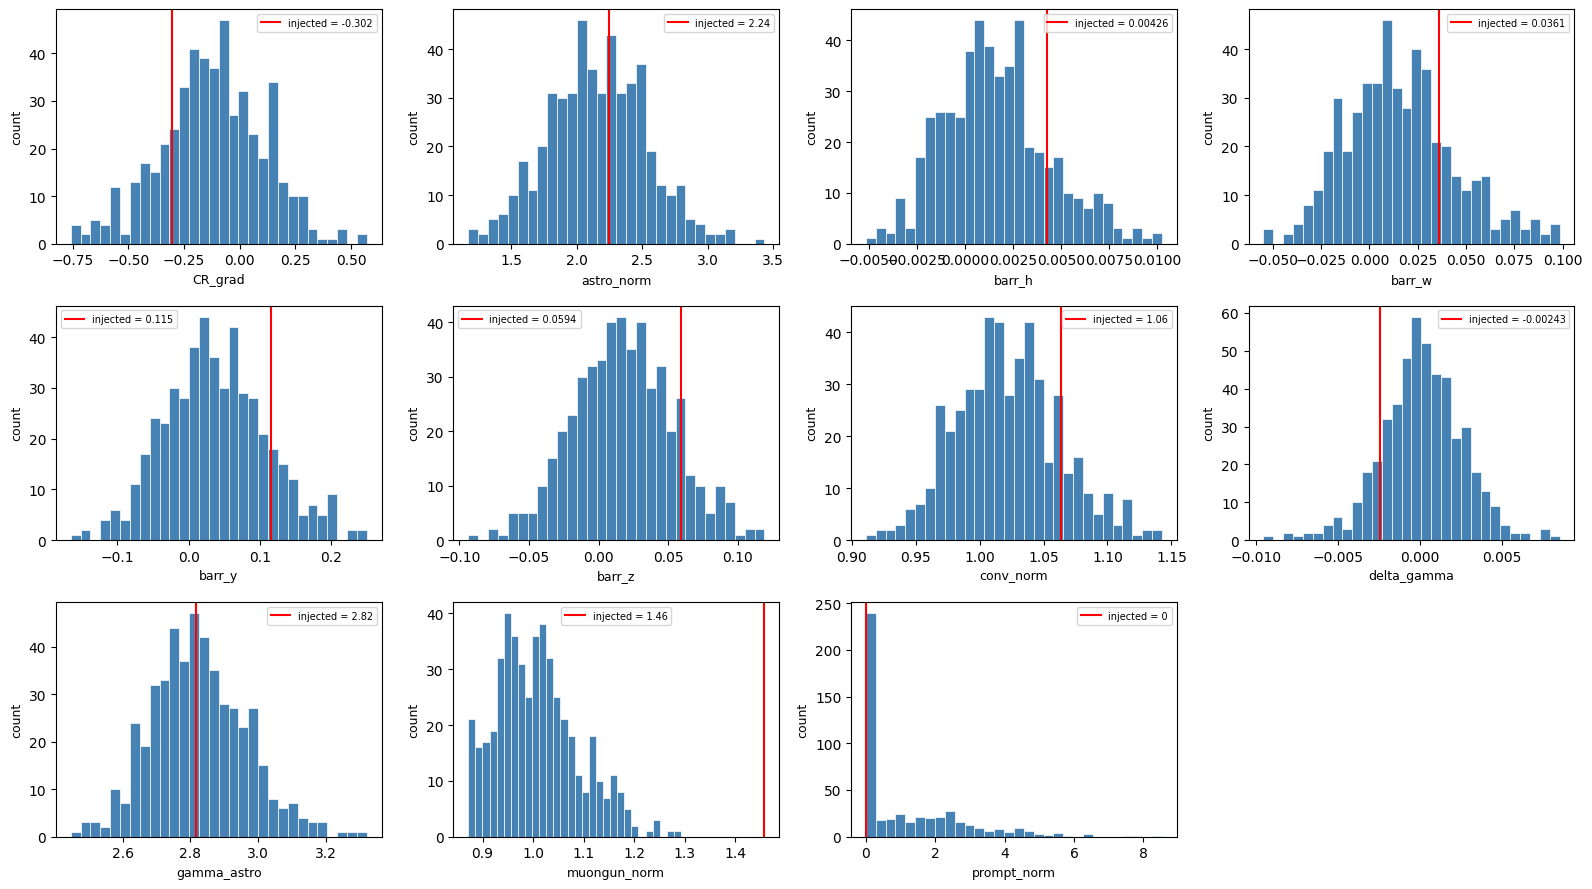

In [10]:
import matplotlib.pyplot as plt
import numpy as np

df = hdl.get_pseudoexp_df()
injected = hdl.get_injected_values()

param_cols = [c for c in df.columns if c not in ('llh', 'fit_success')]

ncols = 4
nrows = int(np.ceil(len(param_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = axes.flatten()

for i, param in enumerate(param_cols):
    ax = axes[i]
    ax.hist(df[param].dropna(), bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    if param in injected:
        inj_val = injected[param]
        ax.axvline(inj_val, color='red', linewidth=1.5, label=f'injected = {inj_val:.3g}')
        ax.legend(fontsize=7)
    ax.set_xlabel(param, fontsize=9)
    ax.set_ylabel('count', fontsize=9)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('pse_param_histograms.png', dpi=150)
plt.show()
